In [ ]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import numpy as np
import pandas as pd
import pickle
from datasets import load_dataset, Dataset, load_from_disk
import ast
from datasets import load_dataset, Dataset, DatasetDict
from dataclasses import dataclass, field
from typing import Optional
from tqdm import tqdm
from trl import SFTTrainer
import random
import wandb
tqdm.pandas()


import warnings
warnings.filterwarnings('ignore')

In [ ]:
################ Load Data + Process Data
print("START LOAD DATA")
path = 'data/physionet.org/files/clinical-bert-mimic-notes/1.0.0/setup_outputs/'
#icd9_descript = pd.read_csv('physionet.org/files/clinical-bert-mimic-notes/1.0.0/setup_outputs/ICD9_Descriptions.csv')
medcat_descript = pd.read_csv(path + 'MedCAT_Descriptions.csv')
reidentified_subject_ids = pd.read_csv(path + 'reidentified_subject_ids.csv')
#subject_id_to_icd9 = pd.read_csv('physionet.org/files/clinical-bert-mimic-notes/1.0.0/setup_outputs/SUBJECT_ID_to_ICD9.csv')
subject_id_to_medcat = pd.read_csv(path + 'SUBJECT_ID_to_MedCAT.csv')
subject_id_to_name = pd.read_csv(path + 'SUBJECT_ID_to_NAME.csv')
subject_id_to_notes_1a = pd.read_csv(path + 'SUBJECT_ID_to_NOTES_1a.csv')
subject_id_to_notes_1b = pd.read_csv(path + 'SUBJECT_ID_to_NOTES_1b.csv')
subject_id_to_notes_templates = pd.read_csv(path + 'SUBJECT_ID_to_NOTES_templates.csv')


with open(file='data/physionet.org/processed_data/train_data.pickle', mode='rb') as f:
    train_data = pickle.load(f)

with open(file='data/physionet.org/processed_data/test_data.pickle', mode='rb') as f:
    test_data = pickle.load(f)
print("DONE LOAD DATA")
    
medcat_name_subject = pd.merge(subject_id_to_medcat, medcat_descript, on='CODE', how='inner')
subject_medcat_names = medcat_name_subject.groupby(['SUBJECT_ID'])['DESCRIPTION'].apply(list).reset_index(name='code_name')

def preprocessing_data(data, df):
    data_new = [list(x) for x in (data[:][0])]

    note = []
    subject_id = []

    for i in data_new:
        note.append(i[0])
        subject_id.append(i[1])

    df_train = pd.DataFrame({'note': note,'SUBJECT_ID': subject_id})

    df_train_merged = df_train.merge(df[['SUBJECT_ID', 'code_name']], on='SUBJECT_ID', how='left')

    return df_train_merged


def processing_df(df_data):
    #df_data['code_name']= df_data['code_name'].apply(lambda x: (ast.literal_eval(x)))
    df_data['condition_nums'] = df_data['code_name'].apply(lambda x: len(x))

    subject_id_to_name['FULL_NAME'] = subject_id_to_name['FIRST_NAME'] + ' ' + subject_id_to_name['LAST_NAME']
    fin_df = pd.merge(subject_id_to_name[['SUBJECT_ID', 'FULL_NAME']], df_data, on='SUBJECT_ID', how='inner')

    fin_df = fin_df[['SUBJECT_ID', 'FULL_NAME', 'condition_nums', 'note', 'code_name']]
    fin_df.columns = ['SUBJECT_ID', 'name', 'num', 'note', 'condition']

    fin_df['condition'] = fin_df['condition'].apply(lambda x: ", ".join(x))

    return fin_df

print("START preprocessing_data(train_data, subject_medcat_names)")
train_df = preprocessing_data(train_data, subject_medcat_names)

print("START preprocessing_data(train_data, subject_medcat_names)")
test_df = preprocessing_data(test_data, subject_medcat_names)

print("START processing_df(train_df)")
df_train = processing_df(train_df)

print("START processing_df(test_df)")
df_test = processing_df(test_df)

In [4]:
df_train_sort = df_train.sort_values('num', ascending=True)
df_train_sort

,SUBJECT_ID,name,num,note,condition
4041,5483,Helaine Pesola,1,Helaine Pesola neonatology attending triage no...,Heart Diseases
17767,22614,Odetta Kaschak,1,Odetta Kaschak neonatology patient is gram pro...,Facial paralysis
1830,2495,Greg Ty,1,Greg Ty nursing admission note - pt admitted f...,Sleeplessness
966,1336,Tish Kuruvilla,1,Tish Kuruvilla admit info please see hx/functi...,Coughing
17771,22619,Lizzie Florida,1,Lizzie Florida nicu nursing note/sepsis work u...,Congenital glucose-galactose malabsorption
...,...,...,...,...,...
33178,69295,Librado Lulgjuraj,222,"Librado Lulgjuraj gastrointestinal bleed, lowe...","alkaloses, Chest Pain, Chest Pain, Coughing, E..."
3648,4962,Rona Gaxiola,236,Rona Gaxiola yo male admitted through er.\nRon...,"Chest Pain, Chest Pain, Coughing, Coughing, Di..."
33466,70516,Michaeline Vanheel,252,Michaeline Vanheel ms vanheel is a y/o lady wi...,"alkaloses, alkaloses, Chest Pain, Chest Pain, ..."
32284,65582,Zoraida Angermeier,264,Zoraida Angermeier mr angermeier is a yo m tra...,"alkaloses, alkaloses, Chest Pain, Chest Pain, ..."


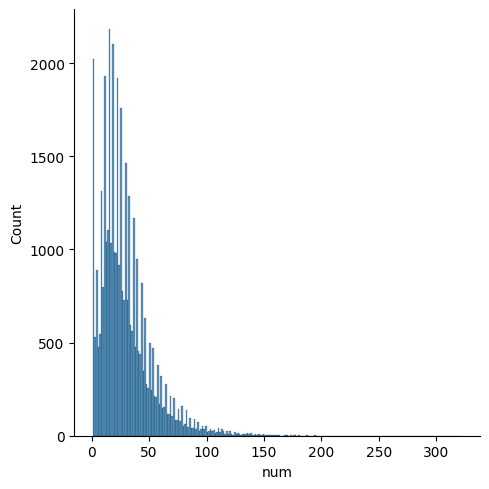

In [5]:
import seaborn as sns
import matplotlib as plt

sns.displot(df_train_sort.num)
#plt.figure(figsize=(15,8))

In [6]:
targets = df_train_sort.num.unique()
targets

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 167, 168, 169, 171, 172,
       173, 174, 175, 176, 177, 180, 181, 184, 186, 187, 188, 19

In [7]:
sample_a = df_train_sort[df_train_sort['num']==targets[0]].sample(n=2, replace=False, random_state=42)[['SUBJECT_ID', 'name', 'condition', 'num']]

for i in range(1, len(targets), 2):
    x = df_train_sort[df_train_sort['num']==targets[i]].sample(n=1, replace=False, random_state=42)[['SUBJECT_ID', 'name', 'condition', 'num']]
    sample_a = pd.concat([sample_a, x], axis=0)

In [8]:
bin = len(targets) // 3
bin

65

In [9]:
sample_a['a'] = sample_a['num'].apply(lambda x: 1 if x<=bin else (2 if x<=2*bin else 3))

sample_a = sample_a[['SUBJECT_ID', 'name', 'a', 'condition', 'num']]
sample_a.columns = ['SUBJECT_ID', 'name', 'a', 'condition', 'condition_nums']

In [10]:
sample_a

,SUBJECT_ID,name,a,condition,condition_nums
24144,30242,Leigh Appelt,1,Dyspnea,1
22148,27830,Stefanie Serda,1,Fever,1
7812,10410,Ilean Moores,1,"Hypoglycemia, Rubella",2
7851,10460,Lyndon Vasta,1,"Urinary tract infection, Lethargy, Nephrolithi...",4
14367,18499,Alexandra Mcginness,1,"Edema, Nausea, Pain, Weakness, Obesity, Neck Pain",6
...,...,...,...,...,...
10771,14131,Evelyn Thakur,3,"alkaloses, Chest Pain, Chest Pain, Coronary Ar...",208
5704,7695,Shirl Kenison,3,"alkaloses, alkaloses, Chest Pain, Chest Pain, ...",213
33178,69295,Librado Lulgjuraj,3,"alkaloses, Chest Pain, Chest Pain, Coughing, E...",222
33466,70516,Michaeline Vanheel,3,"alkaloses, alkaloses, Chest Pain, Chest Pain, ...",252


In [ ]:
sample_a.a.value_counts()

In [11]:
sample_a.to_csv('sample_a.csv', index=False)